<a href="https://colab.research.google.com/github/poovarasi21/InsightStream/blob/main/Copy_of_Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

classes = [
    "Healthy",
    "Early_Blight",
    "Late_Blight",
    "Bacterial_Spot",
    "Septoria_Leaf_Spot",
    "Yellow_Leaf_Curl_Virus"
]

base_dir = "/content/tomato_dataset"

for class_name in classes:
    folder_path = os.path.join(base_dir, class_name)
    os.makedirs(folder_path, exist_ok=True)

print("Tomato dataset folders created successfully!\n")

for class_name in classes:
    print(os.path.join(base_dir, class_name))


Tomato dataset folders created successfully!

/content/tomato_dataset/Healthy
/content/tomato_dataset/Early_Blight
/content/tomato_dataset/Late_Blight
/content/tomato_dataset/Bacterial_Spot
/content/tomato_dataset/Septoria_Leaf_Spot
/content/tomato_dataset/Yellow_Leaf_Curl_Virus


In [ ]:
# Check the folders we created

import os

base_dir = "/content/tomato_dataset"

for class_name in os.listdir(base_dir):
    folder = os.path.join(base_dir, class_name)
    print(class_name, "->", len(os.listdir(folder)), "files")

Late_Blight -> 0 files
Yellow_Leaf_Curl_Virus -> 0 files
Bacterial_Spot -> 0 files
Healthy -> 0 files
Septoria_Leaf_Spot -> 0 files
Early_Blight -> 0 files


In [ ]:
# ============================================================
# DOWNLOAD PLANTVILLAGE DATASET
# AND COPY ONLY 6 TOMATO CLASSES
# ============================================================

import os
import shutil
import subprocess

# Download PlantVillage dataset repository
repo_dir = "/content/PlantVillage-Dataset"

if not os.path.exists(repo_dir):
    print("Downloading PlantVillage dataset...")
    subprocess.run([
        "git", "clone",
        "--depth", "1",
        "https://github.com/spMohanty/PlantVillage-Dataset.git",
        repo_dir
    ], check=True)
else:
    print("PlantVillage repository already exists.")

# Our destination
destination = "/content/tomato_dataset"

# PlantVillage class names -> our class names
class_mapping = {
    "Tomato___healthy": "Healthy",
    "Tomato___Early_blight": "Early_Blight",
    "Tomato___Late_blight": "Late_Blight",
    "Tomato___Bacterial_spot": "Bacterial_Spot",
    "Tomato___Septoria_leaf_spot": "Septoria_Leaf_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Yellow_Leaf_Curl_Virus"
}

print("\nSearching for required tomato classes...\n")

copied_total = 0

for source_class, target_class in class_mapping.items():

    # Search inside the downloaded repository
    source_path = None

    for root, dirs, files in os.walk(repo_dir):
        if os.path.basename(root) == source_class:
            source_path = root
            break

    if source_path is None:
        print("NOT FOUND:", source_class)
        continue

    target_path = os.path.join(destination, target_class)
    os.makedirs(target_path, exist_ok=True)

    count = 0

    for filename in os.listdir(source_path):

        source_file = os.path.join(source_path, filename)

        if os.path.isfile(source_file):
            extension = filename.lower()

            if extension.endswith((".jpg", ".jpeg", ".png", ".bmp")):

                target_file = os.path.join(
                    target_path,
                    filename
                )

                shutil.copy2(source_file, target_file)
                count += 1

    copied_total += count

    print(
        f"{source_class}  -->  {target_class}  :  {count} images"
    )

print("\n======================================")
print("COPY COMPLETED")
print("Total images copied:", copied_total)
print("======================================")


Searching for required tomato classes...

Tomato___healthy  -->  Healthy  :  1591 images
Tomato___Early_blight  -->  Early_Blight  :  1000 images
Tomato___Late_blight  -->  Late_Blight  :  1909 images
Tomato___Bacterial_spot  -->  Bacterial_Spot  :  2127 images
Tomato___Septoria_leaf_spot  -->  Septoria_Leaf_Spot  :  1771 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus  -->  Yellow_Leaf_Curl_Virus  :  5357 images

COPY COMPLETED
Total images copied: 13755


In [ ]:
import os

base_dir = "/content/tomato_dataset"

print("FINAL TOMATO DATASET\n")

total = 0

for class_name in sorted(os.listdir(base_dir)):

    folder = os.path.join(base_dir, class_name)

    if os.path.isdir(folder):

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ])

        total += count

        print(f"{class_name:30} {count} images")

print("\nTotal images:", total)

FINAL TOMATO DATASET

Bacterial_Spot                 2127 images
Early_Blight                   1000 images
Healthy                        1591 images
Late_Blight                    1909 images
Septoria_Leaf_Spot             1771 images
Yellow_Leaf_Curl_Virus         5357 images

Total images: 13755


In [ ]:
# ============================================================
# VERIFY ALL 6 TOMATO CLASSES
# ============================================================

import os

base_dir = "/content/tomato_dataset"

required_classes = [
    "Healthy",
    "Early_Blight",
    "Late_Blight",
    "Bacterial_Spot",
    "Septoria_Leaf_Spot",
    "Yellow_Leaf_Curl_Virus"
]

print("TOMATO DATASET VERIFICATION")
print("=" * 55)

total_images = 0
all_classes_ok = True

for class_name in required_classes:

    folder_path = os.path.join(base_dir, class_name)

    if not os.path.exists(folder_path):
        print(f"❌ {class_name:30} FOLDER MISSING")
        all_classes_ok = False
        continue

    image_files = [
        f for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    count = len(image_files)
    total_images += count

    if count > 0:
        print(f"✅ {class_name:30} {count:6} images")
    else:
        print(f"⚠️ {class_name:30} {count:6} images")
        all_classes_ok = False

print("=" * 55)
print(f"TOTAL IMAGES: {total_images}")

if all_classes_ok:
    print("\n✅ ALL 6 TOMATO CLASSES ARE PRESENT")
else:
    print("\n⚠️ CHECK THE CLASSES MARKED ABOVE")

TOMATO DATASET VERIFICATION
✅ Healthy                          1591 images
✅ Early_Blight                     1000 images
✅ Late_Blight                      1909 images
✅ Bacterial_Spot                   2127 images
✅ Septoria_Leaf_Spot               1771 images
✅ Yellow_Leaf_Curl_Virus           5357 images
TOTAL IMAGES: 13755

✅ ALL 6 TOMATO CLASSES ARE PRESENT


In [ ]:
# ============================================================
# SPLIT TOMATO DATASET
# 70% TRAIN / 15% VALIDATION / 15% TEST
# ============================================================

import os
import shutil
import random

SOURCE_DIR = "/content/tomato_dataset"
OUTPUT_DIR = "/content/tomato_split"

CLASSES = [
    "Healthy",
    "Early_Blight",
    "Late_Blight",
    "Bacterial_Spot",
    "Septoria_Leaf_Spot",
    "Yellow_Leaf_Curl_Virus"
]

# Fixed random seed
SEED = 42
random.seed(SEED)

# Split ratios
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Create output folders
for split in ["train", "validation", "test"]:
    for class_name in CLASSES:
        os.makedirs(
            os.path.join(OUTPUT_DIR, split, class_name),
            exist_ok=True
        )

print("Splitting dataset...\n")

# Split each class separately
for class_name in CLASSES:

    source_class_dir = os.path.join(SOURCE_DIR, class_name)

    images = [
        f for f in os.listdir(source_class_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
    ]

    # Shuffle with fixed seed
    random.shuffle(images)

    total = len(images)

    train_count = int(total * TRAIN_RATIO)
    val_count = int(total * VAL_RATIO)

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    # Copy files
    for filename in train_images:
        shutil.copy2(
            os.path.join(source_class_dir, filename),
            os.path.join(OUTPUT_DIR, "train", class_name, filename)
        )

    for filename in val_images:
        shutil.copy2(
            os.path.join(source_class_dir, filename),
            os.path.join(OUTPUT_DIR, "validation", class_name, filename)
        )

    for filename in test_images:
        shutil.copy2(
            os.path.join(source_class_dir, filename),
            os.path.join(OUTPUT_DIR, "test", class_name, filename)
        )

    print(
        f"{class_name}: "
        f"Total={total}, "
        f"Train={len(train_images)}, "
        f"Validation={len(val_images)}, "
        f"Test={len(test_images)}"
    )

print("\n==========================================")
print("DATASET SPLIT COMPLETED")
print("==========================================")
print("Train      :", os.path.join(OUTPUT_DIR, "train"))
print("Validation :", os.path.join(OUTPUT_DIR, "validation"))
print("Test       :", os.path.join(OUTPUT_DIR, "test"))

Splitting dataset...

Healthy: Total=1591, Train=1113, Validation=238, Test=240
Early_Blight: Total=1000, Train=700, Validation=150, Test=150
Late_Blight: Total=1909, Train=1336, Validation=286, Test=287
Bacterial_Spot: Total=2127, Train=1488, Validation=319, Test=320
Septoria_Leaf_Spot: Total=1771, Train=1239, Validation=265, Test=267
Yellow_Leaf_Curl_Virus: Total=5357, Train=3749, Validation=803, Test=805

DATASET SPLIT COMPLETED
Train      : /content/tomato_split/train
Validation : /content/tomato_split/validation
Test       : /content/tomato_split/test


In [ ]:
# ============================================================
# VERIFY TRAIN / VALIDATION / TEST COUNTS
# ============================================================

import os

for split in ["train", "validation", "test"]:

    print("\n" + "=" * 50)
    print(split.upper())
    print("=" * 50)

    split_total = 0

    for class_name in CLASSES:

        folder = os.path.join(
            OUTPUT_DIR,
            split,
            class_name
        )

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ])

        split_total += count

        print(f"{class_name:30} {count}")

    print("-" * 50)
    print("Total:", split_total)


TRAIN
Healthy                        1113
Early_Blight                   700
Late_Blight                    1336
Bacterial_Spot                 1488
Septoria_Leaf_Spot             1239
Yellow_Leaf_Curl_Virus         3749
--------------------------------------------------
Total: 9625

VALIDATION
Healthy                        238
Early_Blight                   150
Late_Blight                    286
Bacterial_Spot                 319
Septoria_Leaf_Spot             265
Yellow_Leaf_Curl_Virus         803
--------------------------------------------------
Total: 2061

TEST
Healthy                        240
Early_Blight                   150
Late_Blight                    287
Bacterial_Spot                 320
Septoria_Leaf_Spot             267
Yellow_Leaf_Curl_Virus         805
--------------------------------------------------
Total: 2069


In [ ]:
# ============================================================
# VERIFY TRAIN / VALIDATION / TEST COUNTS
# ============================================================

import os

for split in ["train", "validation", "test"]:

    print("\n" + "=" * 50)
    print(split.upper())
    print("=" * 50)

    split_total = 0

    for class_name in CLASSES:

        folder = os.path.join(
            OUTPUT_DIR,
            split,
            class_name
        )

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))
        ])

        split_total += count

        print(f"{class_name:30} {count}")

    print("-" * 50)
    print("Total:", split_total)


TRAIN
Healthy                        1113
Early_Blight                   700
Late_Blight                    1336
Bacterial_Spot                 1488
Septoria_Leaf_Spot             1239
Yellow_Leaf_Curl_Virus         3749
--------------------------------------------------
Total: 9625

VALIDATION
Healthy                        238
Early_Blight                   150
Late_Blight                    286
Bacterial_Spot                 319
Septoria_Leaf_Spot             265
Yellow_Leaf_Curl_Virus         803
--------------------------------------------------
Total: 2061

TEST
Healthy                        240
Early_Blight                   150
Late_Blight                    287
Bacterial_Spot                 320
Septoria_Leaf_Spot             267
Yellow_Leaf_Curl_Virus         805
--------------------------------------------------
Total: 2069


In [ ]:
# ============================================================
# VERIFY TRAIN / VALIDATION / TEST IMAGE COUNTS
# ============================================================

import os

OUTPUT_DIR = "/content/tomato_split"

CLASSES = [
    "Healthy",
    "Early_Blight",
    "Late_Blight",
    "Bacterial_Spot",
    "Septoria_Leaf_Spot",
    "Yellow_Leaf_Curl_Virus"
]

SPLITS = ["train", "validation", "test"]

grand_total = 0

for split in SPLITS:

    print("\n" + "=" * 65)
    print(split.upper())
    print("=" * 65)

    split_total = 0

    for class_name in CLASSES:

        folder = os.path.join(
            OUTPUT_DIR,
            split,
            class_name
        )

        if not os.path.exists(folder):
            print(f"❌ {class_name:30} FOLDER MISSING")
            continue

        image_count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp", ".webp")
            )
        ])

        split_total += image_count

        print(f"{class_name:30} {image_count:6} images")

    print("-" * 65)
    print(f"{split.upper()} TOTAL: {split_total}")

    grand_total += split_total

print("\n" + "=" * 65)
print(f"GRAND TOTAL: {grand_total}")
print("=" * 65)


TRAIN
Healthy                          1113 images
Early_Blight                      700 images
Late_Blight                      1336 images
Bacterial_Spot                   1488 images
Septoria_Leaf_Spot               1239 images
Yellow_Leaf_Curl_Virus           3749 images
-----------------------------------------------------------------
TRAIN TOTAL: 9625

VALIDATION
Healthy                           238 images
Early_Blight                      150 images
Late_Blight                       286 images
Bacterial_Spot                    319 images
Septoria_Leaf_Spot                265 images
Yellow_Leaf_Curl_Virus            803 images
-----------------------------------------------------------------
VALIDATION TOTAL: 2061

TEST
Healthy                           240 images
Early_Blight                      150 images
Late_Blight                       287 images
Bacterial_Spot                    320 images
Septoria_Leaf_Spot                267 images
Yellow_Leaf_Curl_Virus            805

In [ ]:
# ============================================================
# LOAD TOMATO TRAIN / VALIDATION / TEST DATASETS
# ============================================================

import tensorflow as tf

DATASET_DIR = "/content/tomato_split"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# ------------------------------------------------------------
# TRAIN DATASET
# ------------------------------------------------------------

train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_DIR}/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="int"
)

# ------------------------------------------------------------
# VALIDATION DATASET
# ------------------------------------------------------------

val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_DIR}/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

# ------------------------------------------------------------
# TEST DATASET
# ------------------------------------------------------------

test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATASET_DIR}/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

# ------------------------------------------------------------
# CLASS NAMES
# ------------------------------------------------------------

class_names = train_ds.class_names

print("\n==============================================")
print("TOMATO DATASETS LOADED")
print("==============================================")

print("\nClass names and indices:")

for index, class_name in enumerate(class_names):
    print(index, "->", class_name)

print("\nNumber of classes:", len(class_names))

print("\nImage size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

print("\nTrain batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_ds).numpy())

Found 9625 files belonging to 6 classes.
Found 2061 files belonging to 6 classes.
Found 2069 files belonging to 6 classes.

TOMATO DATASETS LOADED

Class names and indices:
0 -> Bacterial_Spot
1 -> Early_Blight
2 -> Healthy
3 -> Late_Blight
4 -> Septoria_Leaf_Spot
5 -> Yellow_Leaf_Curl_Virus

Number of classes: 6

Image size: (224, 224)
Batch size: 32

Train batches: 301
Validation batches: 65
Test batches: 65


TensorFlow class names:
0 -> Bacterial_Spot
1 -> Early_Blight
2 -> Healthy
3 -> Late_Blight
4 -> Septoria_Leaf_Spot
5 -> Yellow_Leaf_Curl_Virus

Expected class names:
0 -> Bacterial_Spot
1 -> Early_Blight
2 -> Healthy
3 -> Late_Blight
4 -> Septoria_Leaf_Spot
5 -> Yellow_Leaf_Curl_Virus

✅ CLASS LABEL CHECK PASSED

Batch image shape: (32, 224, 224, 3)
Batch label shape: (32,)


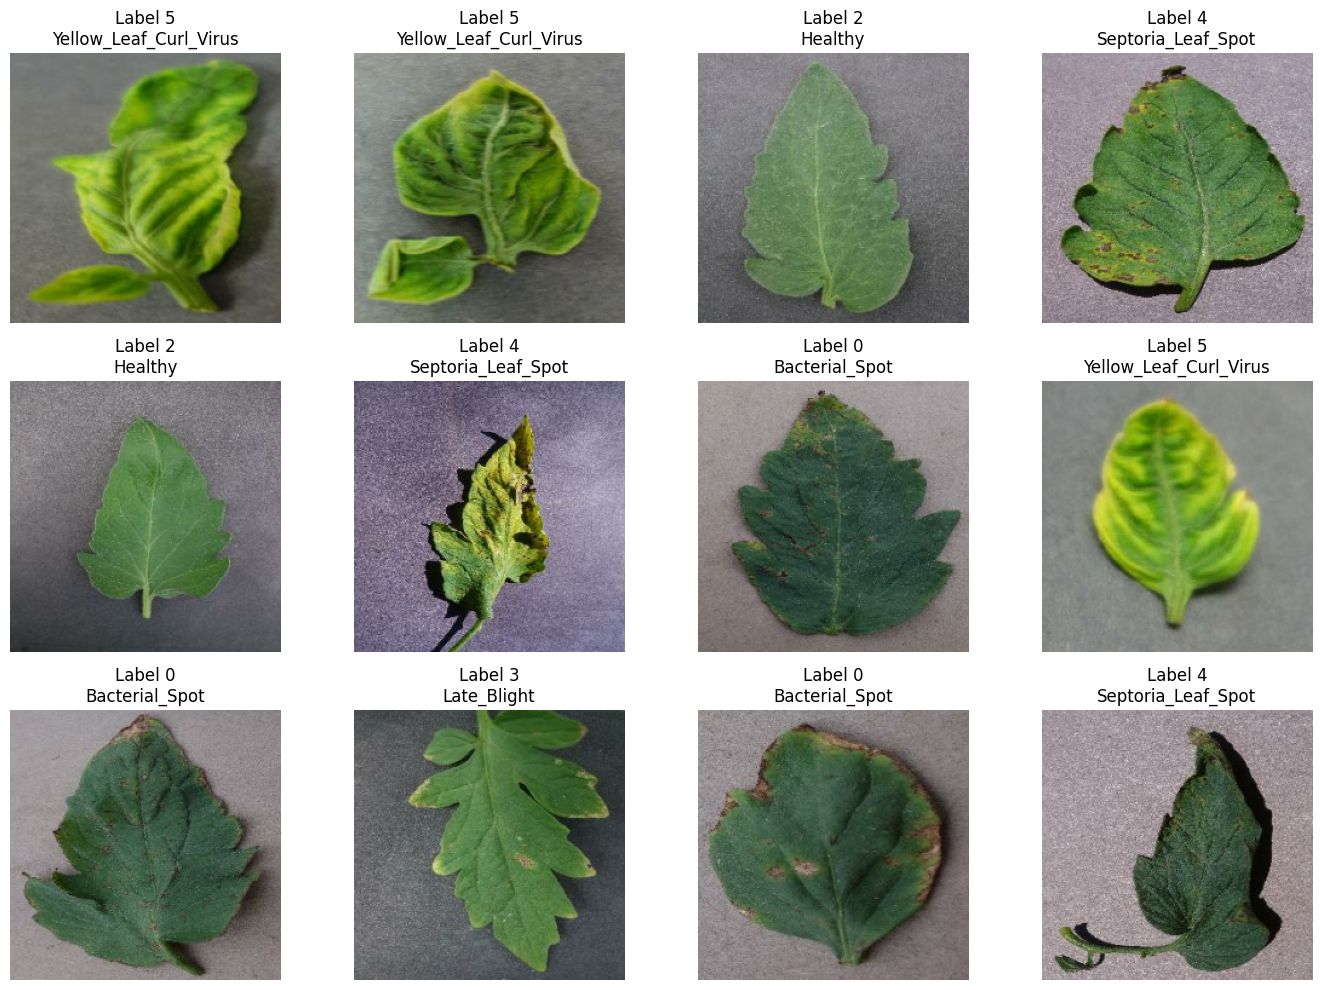


Labels found in this batch:
0 -> Bacterial_Spot
1 -> Early_Blight
2 -> Healthy
3 -> Late_Blight
4 -> Septoria_Leaf_Spot
5 -> Yellow_Leaf_Curl_Virus

✅ IMAGE + LABEL DISPLAY COMPLETED


In [ ]:
# ============================================================
# DISPLAY ONE BATCH AND VERIFY CLASS LABELS
# ============================================================

import matplotlib.pyplot as plt
import tensorflow as tf

# Expected six tomato classes
expected_classes = [
    "Bacterial_Spot",
    "Early_Blight",
    "Healthy",
    "Late_Blight",
    "Septoria_Leaf_Spot",
    "Yellow_Leaf_Curl_Virus"
]

# ------------------------------------------------------------
# 1. VERIFY CLASS NAMES
# ------------------------------------------------------------

print("TensorFlow class names:")
for i, name in enumerate(class_names):
    print(f"{i} -> {name}")

print("\nExpected class names:")
for i, name in enumerate(expected_classes):
    print(f"{i} -> {name}")

# Exact class-name check
if class_names == expected_classes:
    print("\n✅ CLASS LABEL CHECK PASSED")
else:
    print("\n❌ CLASS LABEL CHECK FAILED")
    print("Expected:", expected_classes)
    print("Found   :", class_names)

# ------------------------------------------------------------
# 2. GET ONE BATCH
# ------------------------------------------------------------

images, labels = next(iter(train_ds))

print("\nBatch image shape:", images.shape)
print("Batch label shape:", labels.shape)

# ------------------------------------------------------------
# 3. DISPLAY FIRST 12 IMAGES
# ------------------------------------------------------------

plt.figure(figsize=(14, 10))

num_images = min(12, len(images))

for i in range(num_images):

    plt.subplot(3, 4, i + 1)

    plt.imshow(images[i].numpy().astype("uint8"))

    label_index = int(labels[i].numpy())
    label_name = class_names[label_index]

    plt.title(
        f"Label {label_index}\n{label_name}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. VERIFY LABEL INDICES
# ------------------------------------------------------------

print("\nLabels found in this batch:")

unique_labels = sorted(set(labels.numpy().tolist()))

for label_index in unique_labels:
    print(
        f"{label_index} -> {class_names[label_index]}"
    )

print("\n✅ IMAGE + LABEL DISPLAY COMPLETED")

In [ ]:
# ============================================================
# MOBILE NET V3 LARGE - TRANSFER LEARNING MODEL
# 6 TOMATO CLASSES
# ============================================================

import tensorflow as tf

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

IMG_SIZE = (224, 224)
NUM_CLASSES = 6

print("TensorFlow version:", tf.__version__)

# ------------------------------------------------------------
# 1. LOAD PRETRAINED MOBILENETV3-LARGE
# ------------------------------------------------------------

base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze pretrained layers for first training stage
base_model.trainable = False

print("\nMobileNetV3-Large loaded successfully.")
print("Pretrained layers:", len(base_model.layers))
print("Base model trainable:", base_model.trainable)

# ------------------------------------------------------------
# 2. DATA AUGMENTATION
# ------------------------------------------------------------

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.10
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomContrast(
        0.10
    )
])

# ------------------------------------------------------------
# 3. CREATE MODEL INPUT
# ------------------------------------------------------------

inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="image"
)

# Apply augmentation
x = data_augmentation(inputs)

# MobileNetV3 preprocessing
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

# Pretrained MobileNetV3 backbone
x = base_model(
    x,
    training=False
)

# ------------------------------------------------------------
# 4. CLASSIFICATION HEAD
# ------------------------------------------------------------

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(
    0.30
)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="tomato_disease_output"
)(x)

# ------------------------------------------------------------
# 5. FINAL MODEL
# ------------------------------------------------------------

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Tomato_MobileNetV3Large"
)

# ------------------------------------------------------------
# 6. COMPILE MODEL
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)

# ------------------------------------------------------------
# 7. MODEL SUMMARY
# ------------------------------------------------------------

model.summary()

print("\n============================================")
print("MODEL CREATED SUCCESSFULLY")
print("============================================")

print("Model name:", model.name)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Number of classes:", NUM_CLASSES)

print("\nClass mapping:")
for index, name in enumerate(class_names):
    print(index, "->", name)

TensorFlow version: 2.20.0
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

MobileNetV3-Large loaded successfully.
Pretrained layers: 187
Base model trainable: False


Model: "Tomato_MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tomato_disease_output (Dense)   │ (None, 6)              │         5,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,002,118 (11.45 MB)

 Trainable params: 5,766 (22.52 KB)

 Non-trainable params: 2,996,352 (11.43 MB)


MODEL CREATED SUCCESSFULLY
Model name: Tomato_MobileNetV3Large
Input shape: (None, 224, 224, 3)
Output shape: (None, 6)
Number of classes: 6

Class mapping:
0 -> Bacterial_Spot
1 -> Early_Blight
2 -> Healthy
3 -> Late_Blight
4 -> Septoria_Leaf_Spot
5 -> Yellow_Leaf_Curl_Virus


In [ ]:
# ============================================================
# SMART CROP CARE - TOMATO TRAINING DIAGNOSTIC
# ============================================================

import os
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

print("\nDataset folders:")
for path in [
    "/content/tomato_split/train",
    "/content/tomato_split/validation",
    "/content/tomato_split/test"
]:
    print(path, "->", os.path.exists(path))

print("\nGoogle Drive:")
print(
    "/content/drive ->",
    os.path.exists("/content/drive")
)

TensorFlow version: 2.20.0

Dataset folders:
/content/tomato_split/train -> False
/content/tomato_split/validation -> False
/content/tomato_split/test -> False

Google Drive:
/content/drive -> True


In [ ]:
print("MODEL EXISTS:", "model" in globals())
print("TRAIN DATA EXISTS:", "train_ds" in globals())
print("VALIDATION DATA EXISTS:", "val_ds" in globals())
print("TEST DATA EXISTS:", "test_ds" in globals())
print("CLASS NAMES:", class_names if "class_names" in globals() else "MISSING")

if "model" in globals():
    print("MODEL INPUT:", model.input_shape)
    print("MODEL OUTPUT:", model.output_shape)

if "train_ds" in globals():
    print("TRAIN DATA READY")

if "val_ds" in globals():
    print("VALIDATION DATA READY")

MODEL EXISTS: False
TRAIN DATA EXISTS: False
VALIDATION DATA EXISTS: False
TEST DATA EXISTS: False
CLASS NAMES: MISSING


In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

print("Checking Google Drive...")

paths = [
    "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model",
    "/content/drive/MyDrive/tomato_dataset",
    "/content/drive/MyDrive/tomato_split"
]

print("\nDrive folders:")
for path in paths:
    print(path, "->", os.path.exists(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking Google Drive...

Drive folders:
/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model -> True
/content/drive/MyDrive/tomato_dataset -> False
/content/drive/MyDrive/tomato_split -> False


In [ ]:
# ============================================================
# TRAIN MOBILENETV3-LARGE
# TOMATO - 6 CLASSES
# ============================================================

import tensorflow as tf

# Number of epochs
EPOCHS = 15

print("Starting tomato disease model training...")
print("Epochs:", EPOCHS)
print("Classes:", class_names)

# ------------------------------------------------------------
# TRAIN MODEL
# ------------------------------------------------------------

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print("\n============================================")
print("TRAINING COMPLETED")
print("============================================")


Starting tomato disease model training...
Epochs: 15


NameError: name 'class_names' is not defined

In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

print("Checking Google Drive...")

paths = [
    "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model",
    "/content/drive/MyDrive/tomato_dataset",
    "/content/drive/MyDrive/tomato_split"
]

print("\nDrive folders:")
for path in paths:
    print(path, "->", os.path.exists(path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking Google Drive...

Drive folders:
/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model -> True
/content/drive/MyDrive/tomato_dataset -> False
/content/drive/MyDrive/tomato_split -> False


In [ ]:
import os
import shutil
import random
import subprocess

from google.colab import drive

# ============================================================
# 1. CONNECT GOOGLE DRIVE
# ============================================================

drive.mount("/content/drive")

DRIVE_BASE = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"
RAW_DIR = os.path.join(DRIVE_BASE, "tomato_dataset")
SPLIT_DIR = os.path.join(DRIVE_BASE, "tomato_split")

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(SPLIT_DIR, exist_ok=True)

print("Google Drive connected.")
print("Saving dataset here:")
print(DRIVE_BASE)


# ============================================================
# 2. DOWNLOAD PLANTVILLAGE
# ============================================================

REPO_DIR = "/content/PlantVillage-Dataset"

if not os.path.exists(REPO_DIR):
    print("\nDownloading PlantVillage dataset...")
    subprocess.run([
        "git",
        "clone",
        "--depth", "1",
        "https://github.com/spMohanty/PlantVillage-Dataset.git",
        REPO_DIR
    ], check=True)
else:
    print("\nPlantVillage already downloaded.")


# ============================================================
# 3. REQUIRED TOMATO CLASSES
# ============================================================

CLASS_MAPPING = {
    "Tomato___healthy": "Healthy",
    "Tomato___Early_blight": "Early_Blight",
    "Tomato___Late_blight": "Late_Blight",
    "Tomato___Bacterial_spot": "Bacterial_Spot",
    "Tomato___Septoria_leaf_spot": "Septoria_Leaf_Spot",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus": "Yellow_Leaf_Curl_Virus"
}

CLASSES = list(CLASS_MAPPING.values())


# ============================================================
# 4. COPY TOMATO IMAGES TO GOOGLE DRIVE
# ============================================================

print("\nSearching and copying tomato classes...\n")

for source_class, target_class in CLASS_MAPPING.items():

    source_path = None

    for root, dirs, files in os.walk(REPO_DIR):
        if os.path.basename(root) == source_class:
            source_path = root
            break

    if source_path is None:
        print("❌ NOT FOUND:", source_class)
        continue

    target_path = os.path.join(RAW_DIR, target_class)
    os.makedirs(target_path, exist_ok=True)

    copied = 0

    for filename in os.listdir(source_path):

        if filename.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp")
        ):

            source_file = os.path.join(source_path, filename)
            target_file = os.path.join(target_path, filename)

            if not os.path.exists(target_file):
                shutil.copy2(source_file, target_file)

            copied += 1

    print(f"✅ {target_class}: {copied} images")


# ============================================================
# 5. CREATE TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("\nCreating 70/15/15 dataset split...")

random.seed(42)

for split in ["train", "validation", "test"]:
    for class_name in CLASSES:
        os.makedirs(
            os.path.join(SPLIT_DIR, split, class_name),
            exist_ok=True
        )


for class_name in CLASSES:

    source_folder = os.path.join(RAW_DIR, class_name)

    images = [
        f for f in os.listdir(source_folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".bmp")
        )
    ]

    random.shuffle(images)

    total = len(images)

    train_count = int(total * 0.70)
    val_count = int(total * 0.15)

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    split_data = {
        "train": train_images,
        "validation": val_images,
        "test": test_images
    }

    for split, files in split_data.items():

        destination = os.path.join(
            SPLIT_DIR,
            split,
            class_name
        )

        for filename in files:

            source_file = os.path.join(
                source_folder,
                filename
            )

            destination_file = os.path.join(
                destination,
                filename
            )

            if not os.path.exists(destination_file):
                shutil.copy2(
                    source_file,
                    destination_file
                )

    print(
        f"{class_name}: "
        f"Total={total}, "
        f"Train={len(train_images)}, "
        f"Validation={len(val_images)}, "
        f"Test={len(test_images)}"
    )


# ============================================================
# 6. FINAL CHECK
# ============================================================

print("\n==============================================")
print("TOMATO DATASET READY")
print("==============================================")

for split in ["train", "validation", "test"]:

    total = 0

    for class_name in CLASSES:

        folder = os.path.join(
            SPLIT_DIR,
            split,
            class_name
        )

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".bmp")
            )
        ])

        total += count

    print(f"{split.upper():12} : {total} images")

print("\nDataset permanently saved in Google Drive.")
print(SPLIT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected.
Saving dataset here:
/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model

PlantVillage already downloaded.

Searching and copying tomato classes...

✅ Healthy: 1591 images
✅ Early_Blight: 1000 images
✅ Late_Blight: 1909 images
✅ Bacterial_Spot: 2127 images
✅ Septoria_Leaf_Spot: 1771 images
✅ Yellow_Leaf_Curl_Virus: 5357 images

Creating 70/15/15 dataset split...
Healthy: Total=1591, Train=1113, Validation=238, Test=240
Early_Blight: Total=1000, Train=700, Validation=150, Test=150
Late_Blight: Total=1909, Train=1336, Validation=286, Test=287
Bacterial_Spot: Total=2127, Train=1488, Validation=319, Test=320
Septoria_Leaf_Spot: Total=1771, Train=1239, Validation=265, Test=267
Yellow_Leaf_Curl_Virus: Total=5357, Train=3749, Validation=803, Test=805

TOMATO DATASET READY
TRAIN        : 9625 images
VALIDATION   : 2061 images
TEST         : 20

In [ ]:
import tensorflow as tf
import os

# ============================================================
# LOAD TOMATO DATASET FROM GOOGLE DRIVE
# ============================================================

SPLIT_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/tomato_split"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "validation"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

class_names = train_ds.class_names

print("\n============================================")
print("DATASET LOADED SUCCESSFULLY")
print("============================================")

print("\nClass mapping:")

for i, name in enumerate(class_names):
    print(i, "->", name)

print("\nNumber of classes:", len(class_names))

print("\nTrain batches:",
      tf.data.experimental.cardinality(train_ds).numpy())

print("Validation batches:",
      tf.data.experimental.cardinality(val_ds).numpy())

print("Test batches:",
      tf.data.experimental.cardinality(test_ds).numpy())


# ============================================================
# CREATE MOBILENETV3-LARGE MODEL
# ============================================================

NUM_CLASSES = len(class_names)

base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3),
    name="image"
)

x = tf.keras.layers.RandomFlip("horizontal")(inputs)
x = tf.keras.layers.RandomRotation(0.10)(x)
x = tf.keras.layers.RandomZoom(0.10)(x)
x = tf.keras.layers.RandomContrast(0.10)(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dropout(0.30)(x)

outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    name="tomato_disease_output"
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Tomato_MobileNetV3Large"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n============================================")
print("MODEL CREATED SUCCESSFULLY")
print("============================================")

print("Input shape :", model.input_shape)
print("Output shape:", model.output_shape)
print("Classes     :", NUM_CLASSES)

Found 9625 files belonging to 6 classes.
Found 2061 files belonging to 6 classes.
Found 2069 files belonging to 6 classes.

DATASET LOADED SUCCESSFULLY

Class mapping:
0 -> Bacterial_Spot
1 -> Early_Blight
2 -> Healthy
3 -> Late_Blight
4 -> Septoria_Leaf_Spot
5 -> Yellow_Leaf_Curl_Virus

Number of classes: 6

Train batches: 301
Validation batches: 65
Test batches: 65
12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

MODEL CREATED SUCCESSFULLY
Input shape : (None, 224, 224, 3)
Output shape: (None, 6)
Classes     : 6


In [ ]:
import os
import tensorflow as tf

# ============================================================
# TOMATO DISEASE MODEL TRAINING
# WITH AUTOMATIC GOOGLE DRIVE CHECKPOINTS
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "best_tomato_model.keras"
)

FINAL_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "tomato_mobilenetv3_final.keras"
)

# ------------------------------------------------------------
# CHECKPOINT
# ------------------------------------------------------------

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

# ------------------------------------------------------------
# EARLY STOPPING
# ------------------------------------------------------------

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# ------------------------------------------------------------
# TRAINING
# ------------------------------------------------------------

EPOCHS = 15

print("==============================================")
print("STARTING TOMATO DISEASE MODEL TRAINING")
print("==============================================")
print("Classes:", class_names)
print("Epochs:", EPOCHS)
print("Best model:", BEST_MODEL_PATH)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[
        checkpoint,
        early_stopping
    ]
)

# ------------------------------------------------------------
# SAVE FINAL MODEL
# ------------------------------------------------------------

model.save(FINAL_MODEL_PATH)

print("\n==============================================")
print("TRAINING COMPLETED")
print("==============================================")

print("Best model exists:",
      os.path.exists(BEST_MODEL_PATH))

print("Final model exists:",
      os.path.exists(FINAL_MODEL_PATH))

print("\nBest model:")
print(BEST_MODEL_PATH)

print("\nFinal model:")
print(FINAL_MODEL_PATH)

STARTING TOMATO DISEASE MODEL TRAINING
Classes: ['Bacterial_Spot', 'Early_Blight', 'Healthy', 'Late_Blight', 'Septoria_Leaf_Spot', 'Yellow_Leaf_Curl_Virus']
Epochs: 15
Best model: /content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/best_tomato_model.keras
Epoch 1/15
 52/301 ━━━━━━━━━━━━━━━━━━━━ 7:06 2s/step - accuracy: 0.2525 - loss: 2.0733

KeyboardInterrupt: 

In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"

print("Saved model files:")
print("=" * 50)

for file in os.listdir(SAVE_DIR):
    if file.endswith(".keras"):
        path = os.path.join(SAVE_DIR, file)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"✅ {file}  |  {size_mb:.2f} MB")

Saved model files:


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"

print("BEST MODEL:")
model_path = os.path.join(SAVE_DIR, "best_tomato_model.keras")
print(model_path)
print("Exists:", os.path.exists(model_path))

print("\nDATASET:")
split_dir = os.path.join(SAVE_DIR, "tomato_split")

for split in ["train", "validation", "test"]:
    path = os.path.join(split_dir, split)
    print(split, "->", os.path.exists(path))

print("\nCURRENT VARIABLES:")
print("test_ds exists:", "test_ds" in globals())
print("class_names exists:", "class_names" in globals())

BEST MODEL:
/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/best_tomato_model.keras
Exists: False

DATASET:
train -> True
validation -> True
test -> True

CURRENT VARIABLES:
test_ds exists: True
class_names exists: True


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"

# Saved model
model_path = os.path.join(
    SAVE_DIR,
    "best_tomato_model.keras"
)

# Test dataset
test_path = os.path.join(
    SAVE_DIR,
    "tomato_split",
    "test"
)

print("==============================================")
print("DRIVE MODEL + TEST DATASET CHECK")
print("==============================================")

print("\nSaved model:")
print(model_path)
print("Exists:", os.path.exists(model_path))

if os.path.exists(model_path):
    size_mb = os.path.getsize(model_path) / (1024 * 1024)
    print(f"Size: {size_mb:.2f} MB")

print("\nTest dataset:")
print(test_path)
print("Exists:", os.path.exists(test_path))

if os.path.exists(test_path):
    print("\nTest classes:")
    for class_name in sorted(os.listdir(test_path)):
        class_path = os.path.join(test_path, class_name)

        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(
                    (".jpg", ".jpeg", ".png", ".bmp")
                )
            ])
            print(f"{class_name}: {count} images")

print("\n==============================================")
print("CHECK COMPLETED")
print("==============================================")

DRIVE MODEL + TEST DATASET CHECK

Saved model:
/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/best_tomato_model.keras
Exists: False

Test dataset:
/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/tomato_split/test
Exists: True

Test classes:
Bacterial_Spot: 320 images
Early_Blight: 150 images
Healthy: 240 images
Late_Blight: 287 images
Septoria_Leaf_Spot: 267 images
Yellow_Leaf_Curl_Virus: 805 images

CHECK COMPLETED


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"

print("=== DRIVE CHECK ===")

for root, dirs, files in os.walk(SAVE_DIR):
    level = root.replace(SAVE_DIR, "").count(os.sep)

    if level > 2:
        continue

    indent = "  " * level
    print(indent + os.path.basename(root) + "/")

    for file in files:
        if file.endswith((".keras", ".tflite", ".txt")):
            size_mb = os.path.getsize(os.path.join(root, file)) / (1024 * 1024)
            print(indent + "  " + file + f" ({size_mb:.2f} MB)")

print("\n=== SPECIFIC MODEL CHECK ===")

model_path = os.path.join(
    SAVE_DIR,
    "best_tomato_model.keras"
)

print("Model path:", model_path)
print("Model exists:", os.path.isfile(model_path))

=== DRIVE CHECK ===
Smart_Crop_Care_Tomato_Model/
  tomato_dataset/
    Healthy/
    Early_Blight/
    Late_Blight/
    Bacterial_Spot/
    Septoria_Leaf_Spot/
    Yellow_Leaf_Curl_Virus/
  tomato_split/
    train/
    validation/
    test/

=== SPECIFIC MODEL CHECK ===
Model path: /content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/best_tomato_model.keras
Model exists: False


In [ ]:
import os

SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"
MODEL_PATH = os.path.join(SAVE_DIR, "best_tomato_model.keras")

if os.path.isfile(MODEL_PATH):
    print("✅ SAVED MODEL FOUND")
    print("File:", MODEL_PATH)
    print("Size:", round(os.path.getsize(MODEL_PATH) / (1024 * 1024), 2), "MB")
else:
    print("❌ SAVED MODEL NOT FOUND")
    print("Expected location:")
    print(MODEL_PATH)

❌ SAVED MODEL NOT FOUND
Expected location:
/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/best_tomato_model.keras


In [ ]:
import os

DRIVE_ROOT = "/content/drive/MyDrive"

print("Searching Google Drive for trained Keras models...")
print("=" * 60)

found = []

for root, dirs, files in os.walk(DRIVE_ROOT):
    for file in files:
        if file.lower().endswith((".keras", ".h5")):
            path = os.path.join(root, file)
            size_mb = os.path.getsize(path) / (1024 * 1024)
            found.append((path, size_mb))

if found:
    print("\n✅ MODEL FILES FOUND:\n")

    for path, size_mb in found:
        print(f"📁 {path}")
        print(f"   Size: {size_mb:.2f} MB\n")
else:
    print("\n❌ NO .keras OR .h5 MODEL FOUND IN GOOGLE DRIVE")

Searching Google Drive for trained Keras models...

❌ NO .keras OR .h5 MODEL FOUND IN GOOGLE DRIVE


In [ ]:
import os
import tensorflow as tf

SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"
os.makedirs(SAVE_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    SAVE_DIR,
    "tomato_checkpoint.weights.h5"
)

print("Starting safe training...")
print("Checkpoint:", CHECKPOINT_PATH)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint, early_stop]
)

print("\n================================")
print("TRAINING FINISHED")
print("================================")
print(
    "Checkpoint saved:",
    os.path.exists(CHECKPOINT_PATH)
)

Starting safe training...
Checkpoint: /content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/tomato_checkpoint.weights.h5
Epoch 1/15
301/301 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4295 - loss: 1.5116

KeyboardInterrupt: 

In [ ]:
import traceback
import os
import tensorflow as tf

print("==============================================")
print("TOMATO MODEL TRAINING - DEBUG MODE")
print("==============================================")

try:

    # Check required variables
    print("\nChecking required variables...")

    required = [
        "model",
        "train_ds",
        "val_ds",
        "class_names"
    ]

    for name in required:
        if name in globals():
            print(f"✅ {name} exists")
        else:
            print(f"❌ {name} MISSING")

    # Check model
    if "model" not in globals():
        raise RuntimeError(
            "MODEL is missing. Create the MobileNetV3 model first."
        )

    # Check datasets
    if "train_ds" not in globals():
        raise RuntimeError(
            "TRAIN DATASET is missing."
        )

    if "val_ds" not in globals():
        raise RuntimeError(
            "VALIDATION DATASET is missing."
        )

    # Check class names
    print("\nClass names:")
    print(class_names)

    print("\nModel input :", model.input_shape)
    print("Model output:", model.output_shape)

    # Check one training batch
    print("\nChecking training batch...")

    sample_images, sample_labels = next(iter(train_ds))

    print("Image shape :", sample_images.shape)
    print("Label shape :", sample_labels.shape)

    # Test one forward pass
    print("\nTesting model forward pass...")

    sample_prediction = model(sample_images[:2])

    print("Prediction shape:",
          sample_prediction.shape)

    print("\n==============================================")
    print("PRE-TRAINING CHECK PASSED")
    print("==============================================")

    # Google Drive checkpoint
    SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"
    os.makedirs(SAVE_DIR, exist_ok=True)

    CHECKPOINT_PATH = os.path.join(
        SAVE_DIR,
        "tomato_checkpoint.weights.h5"
    )

    checkpoint = tf.keras.callbacks.ModelCheckpoint(
        CHECKPOINT_PATH,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    )

    print("\nStarting training...")
    print("Checkpoint:")
    print(CHECKPOINT_PATH)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[
            checkpoint,
            early_stop
        ]
    )

    print("\n==============================================")
    print("TRAINING COMPLETED SUCCESSFULLY")
    print("==============================================")

    print(
        "Checkpoint exists:",
        os.path.exists(CHECKPOINT_PATH)
    )

except Exception as e:

    print("\n")
    print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")
    print("❌ TRAINING ERROR")
    print("!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!")

    print("\nError type:")
    print(type(e).__name__)

    print("\nError message:")
    print(str(e))

    print("\nFULL TRACEBACK:")
    traceback.print_exc()

    print("\n==============================================")
    print("DEBUG INFORMATION")
    print("==============================================")

    print("TensorFlow:", tf.__version__)

    print(
        "Google Drive mounted:",
        os.path.exists("/content/drive")
    )

    print(
        "Model exists:",
        "model" in globals()
    )

    print(
        "Train dataset exists:",
        "train_ds" in globals()
    )

    print(
        "Validation dataset exists:",
        "val_ds" in globals()
    )

    print(
        "Class names:",
        class_names if "class_names" in globals()
        else "MISSING"
    )

    print("\n❗ Send me the RED ERROR + FULL TRACEBACK.")

TOMATO MODEL TRAINING - DEBUG MODE

Checking required variables...
✅ model exists
✅ train_ds exists
✅ val_ds exists
✅ class_names exists

Class names:
['Bacterial_Spot', 'Early_Blight', 'Healthy', 'Late_Blight', 'Septoria_Leaf_Spot', 'Yellow_Leaf_Curl_Virus']

Model input : (None, 224, 224, 3)
Model output: (None, 6)

Checking training batch...
Image shape : (32, 224, 224, 3)
Label shape : (32,)

Testing model forward pass...


KeyboardInterrupt: 

In [ ]:
import os

CHECKPOINT_PATH = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/tomato_checkpoint.weights.h5"

print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH))

if os.path.exists(CHECKPOINT_PATH):
    size_mb = os.path.getsize(CHECKPOINT_PATH) / (1024 * 1024)
    print("Checkpoint size:", round(size_mb, 2), "MB")
    print("✅ TRAINED WEIGHTS ARE SAVED")
else:
    print("❌ CHECKPOINT NOT FOUND")

Checkpoint exists: False
❌ CHECKPOINT NOT FOUND


In [ ]:
print("MODEL:", "READY" if "model" in globals() else "MISSING")
print("TRAIN DATA:", "READY" if "train_ds" in globals() else "MISSING")
print("VALIDATION DATA:", "READY" if "val_ds" in globals() else "MISSING")
print("CLASS NAMES:", "READY" if "class_names" in globals() else "MISSING")

MODEL: READY
TRAIN DATA: READY
VALIDATION DATA: READY
CLASS NAMES: READY


In [ ]:
import os
import tensorflow as tf

SAVE_DIR = "/content/drive/MyDrive/Smart_Crop_Care_Tomato_Model"
os.makedirs(SAVE_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    SAVE_DIR,
    "tomato_best.weights.h5"
)

BACKUP_DIR = os.path.join(
    SAVE_DIR,
    "training_backup"
)

os.makedirs(BACKUP_DIR, exist_ok=True)

print("==============================================")
print("SAFE TOMATO TRAINING")
print("==============================================")
print("Checkpoint:", CHECKPOINT_PATH)
print("Backup:", BACKUP_DIR)

# Save current model weights first to verify Drive writing works
TEST_SAVE = os.path.join(
    SAVE_DIR,
    "drive_write_test.weights.h5"
)

model.save_weights(TEST_SAVE)

print("\nDrive write test:")
print("Saved:", os.path.exists(TEST_SAVE))

if not os.path.exists(TEST_SAVE):
    raise RuntimeError(
        "Google Drive write failed. Training stopped."
    )

# Automatic best-model checkpoint
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    CHECKPOINT_PATH,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

# Resume-safe training backup
backup = tf.keras.callbacks.BackupAndRestore(
    backup_dir=BACKUP_DIR,
    delete_checkpoint=False
)

# Stop if validation accuracy stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("\nStarting training...")
print("Maximum epochs: 15")

try:

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[
            checkpoint,
            backup,
            early_stop
        ]
    )

    print("\n==============================================")
    print("TRAINING COMPLETED")
    print("==============================================")

except Exception as e:

    print("\n❌ TRAINING ERROR")
    print(type(e).__name__)
    print(str(e))
    raise

finally:

    print("\n==============================================")
    print("DRIVE SAVE CHECK")
    print("==============================================")

    print(
        "Best checkpoint:",
        os.path.exists(CHECKPOINT_PATH)
    )

    if os.path.exists(CHECKPOINT_PATH):
        size_mb = os.path.getsize(CHECKPOINT_PATH) / (1024 * 1024)
        print(f"Checkpoint size: {size_mb:.2f} MB")
        print("✅ TRAINED WEIGHTS ARE SAVED TO GOOGLE DRIVE")
    else:
        print("❌ CHECKPOINT NOT CREATED")

SAFE TOMATO TRAINING
Checkpoint: /content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/tomato_best.weights.h5
Backup: /content/drive/MyDrive/Smart_Crop_Care_Tomato_Model/training_backup

Drive write test:
Saved: True

Starting training...
Maximum epochs: 15
Epoch 1/15
135/301 ━━━━━━━━━━━━━━━━━━━━ 4:55 2s/step - accuracy: 0.5921 - loss: 1.1004
DRIVE SAVE CHECK
Best checkpoint: False
❌ CHECKPOINT NOT CREATED


KeyboardInterrupt: 